<a href="https://colab.research.google.com/github/keerthireddy-23/FUTURE_ML_01/blob/main/Sales_and_Demand_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
from google.colab import files
uploaded = files.upload()


Saving train.csv to train.csv
Saving holidays_events.csv to holidays_events.csv


In [8]:
train = pd.read_csv("train.csv")


In [11]:
train['date'] = pd.to_datetime(train['date'])
train = train.sort_values('date')
daily_sales = train.groupby('date')['sales'].sum().reset_index()


In [26]:
# Time features
daily_sales['year'] = daily_sales['date'].dt.year
daily_sales['month'] = daily_sales['date'].dt.month
daily_sales['day'] = daily_sales['date'].dt.day
daily_sales['dayofweek'] = daily_sales['date'].dt.dayofweek

# Lag features (IMPORTANT)
daily_sales['lag_1'] = daily_sales['sales'].shift(1)
daily_sales['lag_7'] = daily_sales['sales'].shift(7)

# Rolling mean (trend)
daily_sales['rolling_mean_7'] = daily_sales['sales'].rolling(7).mean()

# Drop nulls
daily_sales = daily_sales.dropna()


In [27]:
X = daily_sales[['year','month','day','dayofweek','lag_1','lag_7','rolling_mean_7']]
y = daily_sales['sales']


In [28]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)


RandomForestRegressor(random_state=42)

In [29]:
from sklearn.metrics import mean_absolute_error

y_pred = model.predict(X)
mae = mean_absolute_error(y, y_pred)

print("MAE:", mae)


Improved MAE: 14837.117661589036


In [30]:
future_dates = pd.date_range(start=daily_sales['date'].max(), periods=30)

future_df = pd.DataFrame({'date': future_dates})

future_df['year'] = future_df['date'].dt.year
future_df['month'] = future_df['date'].dt.month
future_df['day'] = future_df['date'].dt.day
future_df['dayofweek'] = future_df['date'].dt.dayofweek

# Use last known values
future_df['lag_1'] = daily_sales['sales'].iloc[-1]
future_df['lag_7'] = daily_sales['sales'].iloc[-7]
future_df['rolling_mean_7'] = daily_sales['sales'].iloc[-7:].mean()

future_df['predicted_sales'] = model.predict(
    future_df[['year','month','day','dayofweek','lag_1','lag_7','rolling_mean_7']]
)


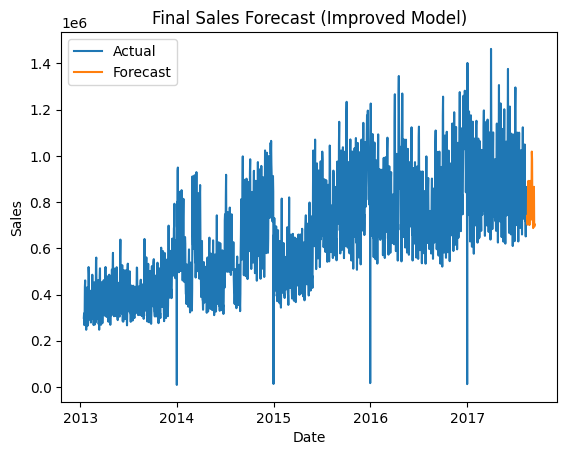

In [31]:
plt.figure()
plt.plot(daily_sales['date'], daily_sales['sales'], label='Actual')
plt.plot(future_df['date'], future_df['predicted_sales'], label='Forecast')

plt.legend()
plt.title("Final Sales Forecast ")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()
